# Atmospheric Deposition

In [12]:
import cmocean.cm as cm
import copy
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
plt.rcParams.update({'font.size': 14})

In [14]:
bathy = xr.open_dataset('gebco_2026_bathy.nc')

In [15]:
brown_gradient = mcolors.LinearSegmentedColormap.from_list(
    "custom_browns", 
    ["#988C81", "#4C3823"]
)
#
colors_water = plt.cm.Blues_r(np.linspace(0, 1, 50))
colors_land = brown_gradient(np.linspace(0, 1, 5))
all_colors = np.vstack((colors_water, colors_land))
cmap_custom = mcolors.ListedColormap(all_colors, name='BathyTopo')
#
data_min = bathy.elevation.min()
data_max = bathy.elevation.max()
#
levels_water = np.linspace(-500, 0, 51)
levels_land = np.linspace(0, data_max, 6)
#
levels = np.concatenate((levels_water[:-1], levels_land))
#
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=len(all_colors))

In [16]:
just_water = bathy.where((bathy.elevation > -500) & (bathy.elevation <=0))
levels_water = np.linspace(-500,0,10)
#
lat_ucluelet, lon_ucluelet = [48.94253162276544, -125.48388075255914]
lat_saturna, lon_saturna = [48.79811488480372, -123.20042739065309]
#
clat = 49.195045
clon = -123.301956

Text(-126.05871327264397, 47.18, '50 km')

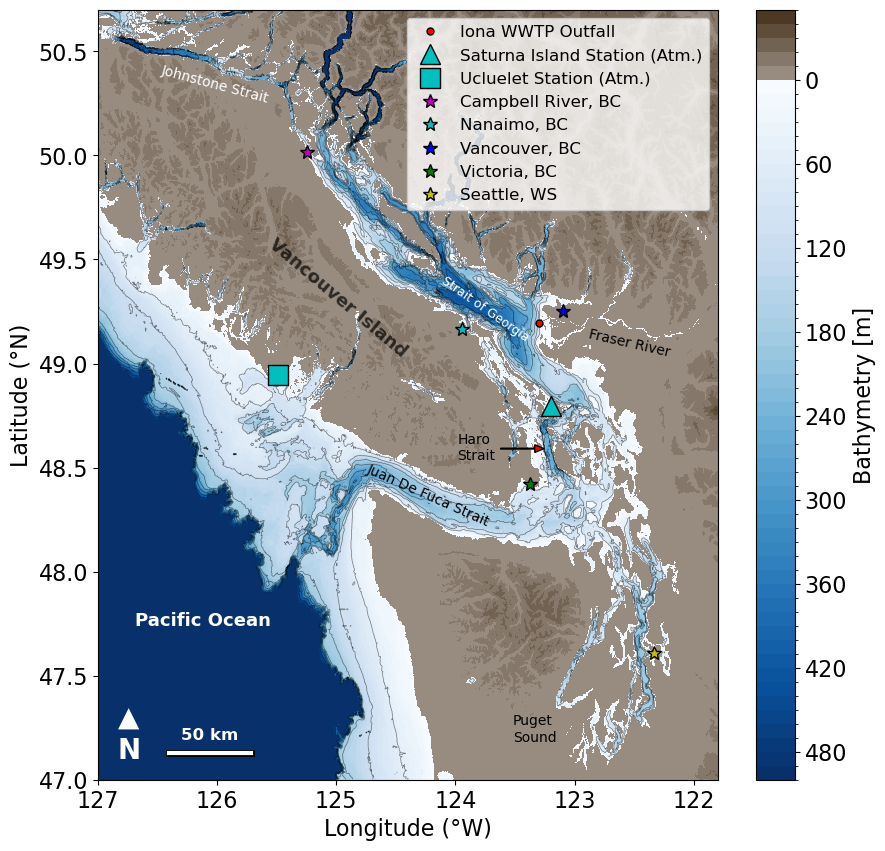

In [21]:
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize = (10,10))
bathymetry = ax.pcolormesh(bathy.lon, bathy.lat, bathy.elevation, cmap=cmap_custom, norm=norm)
ax.contour(just_water.lon, just_water.lat, just_water.elevation, levels = levels_water, colors='black', alpha = .5
           ,linewidths=0.5, linestyles='solid')
ax.set_xlim(-127,-121.8); ax.set_ylim(47, 50.7) 
fmt_x = ticker.FuncFormatter(lambda x, pos: f'{abs(x):g}')
ax.xaxis.set_major_formatter(fmt_x)
ax.set_xlabel('Longitude (°W)');ax.set_ylabel('Latitude (°N)')
cbar = plt.colorbar(bathymetry, ax = ax)
fmt = ticker.FuncFormatter(lambda x, pos: f'{abs(x):.0f}')
cbar.ax.yaxis.set_major_formatter(fmt)
cbar.set_label('Bathymetry [m]')
######################################################
ax.text(0.43, 0.33, 'Juan De Fuca Strait', rotation = -24, transform=ax.transAxes, fontsize = 10, zorder=3)
#ax.arrow(0.20, 0.30,  0.1,  0.070, head_width=0.01, fc='w', ec='b', transform=ax.transAxes, zorder=3)
#
ax.text(0.1, 0.88, 'Johnstone Strait', rotation = -15, transform=ax.transAxes, fontsize = 10, zorder=3, color = 'white')
#
#
ax.plot(clon, clat, 'ko', markersize=5, markerfacecolor='r', zorder=3, label = 'Iona WWTP Outfall')
ax.plot(lon_saturna, lat_saturna, 'k^', markersize=15, markerfacecolor='c', zorder=3, label = 'Saturna Island Station (Atm.)')
ax.plot(lon_ucluelet, lat_ucluelet, 'ks', markersize=15, markerfacecolor='c', zorder=3, label = 'Ucluelet Station (Atm.)')

#
ax.plot(-125.24459, 50.01634, 'k*', markersize=10, markerfacecolor='m', zorder=3, label = 'Campbell River, BC')
ax.plot(-123.94003, 49.16638, 'k*', markersize=10, markerfacecolor='c', zorder=3, label = 'Nanaimo, BC')
ax.plot(-123.10, 49.25, 'k*', markersize=10, markerfacecolor='b', zorder=3, label = 'Vancouver, BC')
ax.plot(-123.37, 48.42, 'k*', markersize=10, markerfacecolor='g', zorder=3, label = 'Victoria, BC')
ax.plot(-122.33, 47.61, 'k*', markersize=10, markerfacecolor='y', zorder=3, label = 'Seattle, WS')
#
ax.text(0.79, 0.55, 'Fraser River', rotation = -13, transform=ax.transAxes, fontsize = 10, zorder=3)
#
# SoG
#
ax.text(0.55, 0.57, 'Strait of Georgia', rotation=-35, transform=ax.transAxes, fontsize = 9, zorder=3, color = 'white')
#
# PS
#
ax.text(0.67, 0.050, 'Puget\nSound', transform=ax.transAxes, fontsize = 10, zorder=3)
#
ax.text(0.06, 0.2, 'Pacific Ocean', transform=ax.transAxes, fontsize = 13, zorder=3, fontweight = 'bold', color = 'white')
#
ax.text(0.27, 0.55, 'Vancouver Island', rotation = -40, transform=ax.transAxes, fontsize = 13, zorder=3, fontweight = 'bold', alpha = .7)
#
ax.text(0.58, 0.415, 'Haro\nStrait', transform=ax.transAxes, fontsize = 10, zorder=3)
ax.arrow(0.65, 0.43,  0.055, 0.0, head_width=0.01, fc='r', ec='k', transform=ax.transAxes, zorder=3)
#
ax.legend(fontsize = 12)
####
####
arrow_x, arrow_y = 0.05, 0.02

ax.text(arrow_x, arrow_y, u'\u25B2\nN', ha='center', va='bottom', 
        transform=ax.transAxes, fontsize=20, fontweight='bold', color='white', zorder=10)


scale_bar_length_km = 50 

lat_center = np.mean(ax.get_ylim())
one_degree_lon_km = 111.32 * np.cos(np.deg2rad(lat_center))
scale_bar_length_deg = scale_bar_length_km / one_degree_lon_km

bar_x = -126.4  
bar_y = 47.13   

ax.plot([bar_x, bar_x + scale_bar_length_deg], [bar_y, bar_y], 
        color='white', linewidth=3, zorder=10) 
ax.plot([bar_x, bar_x + scale_bar_length_deg], [bar_y, bar_y], 
        color='black', linewidth=5, zorder=9) 

ax.text(bar_x + scale_bar_length_deg/2, bar_y + 0.05, f'{scale_bar_length_km} km', 
        ha='center', va='bottom', color='white', fontweight='bold', fontsize=12, zorder=10)
ax.text(bar_x + scale_bar_length_deg/2, bar_y + 0.05, f'{scale_bar_length_km} km', 
        ha='center', va='bottom', color='black', fontweight='bold', fontsize=12, zorder=9, alpha=0.5)

In [22]:
labels = ['BDE-3', 'BDE-47', 'BDE-99', 'BDE-209']
location_color = ['c', 'r',]

# Rain

In [23]:
ucluelet_rain_mean = np.array([5.61, 10.57, 7.86, 65.09]) * 10e-9
ucluelet_rain_std = np.array([2.23, 1.36, 1.48, 14.5]) * 10e-9
#
saturna_rain_mean = np.array([220.81, 499.32, 532.62, 12263.69]) * 10e-9
saturna_rain_std = np.array([73.01, 98.21, 74.27, 4501.96]) * 10e-9

# Particulate Phase

In [24]:
ucluelet_particulate_mean = np.array([0.27, 0.51, 0.42, 0.71]) * 10e-12
ucluelet_particulate_std = np.array([0.07, 0.1, 0.12, 0.26]) * 10e-12
#
saturna_particulate_mean = np.array([0.13, 0.71, 0.83, 1.17]) * 10e-12
saturna_particulate_std = np.array([0.03, 0.09, 0.17, 0.06]) * 10e-12

# Gas Phase

In [25]:
ucluelet_gas_mean = np.array([np.nan, 3.5, 4.82, 0.2]) * 10e-12
ucluelet_gas_std = np.array([np.nan, 1.76, 2.78, 0.05]) * 10e-12
#
saturna_gas_mean = np.array([np.nan, 2.2, 3.07, 0.11]) * 10e-12
saturna_gas_std = np.array([np.nan, 1.52, 2.39, 0.03]) * 10e-12

# PLOTS UCLUELET VS SATURNA

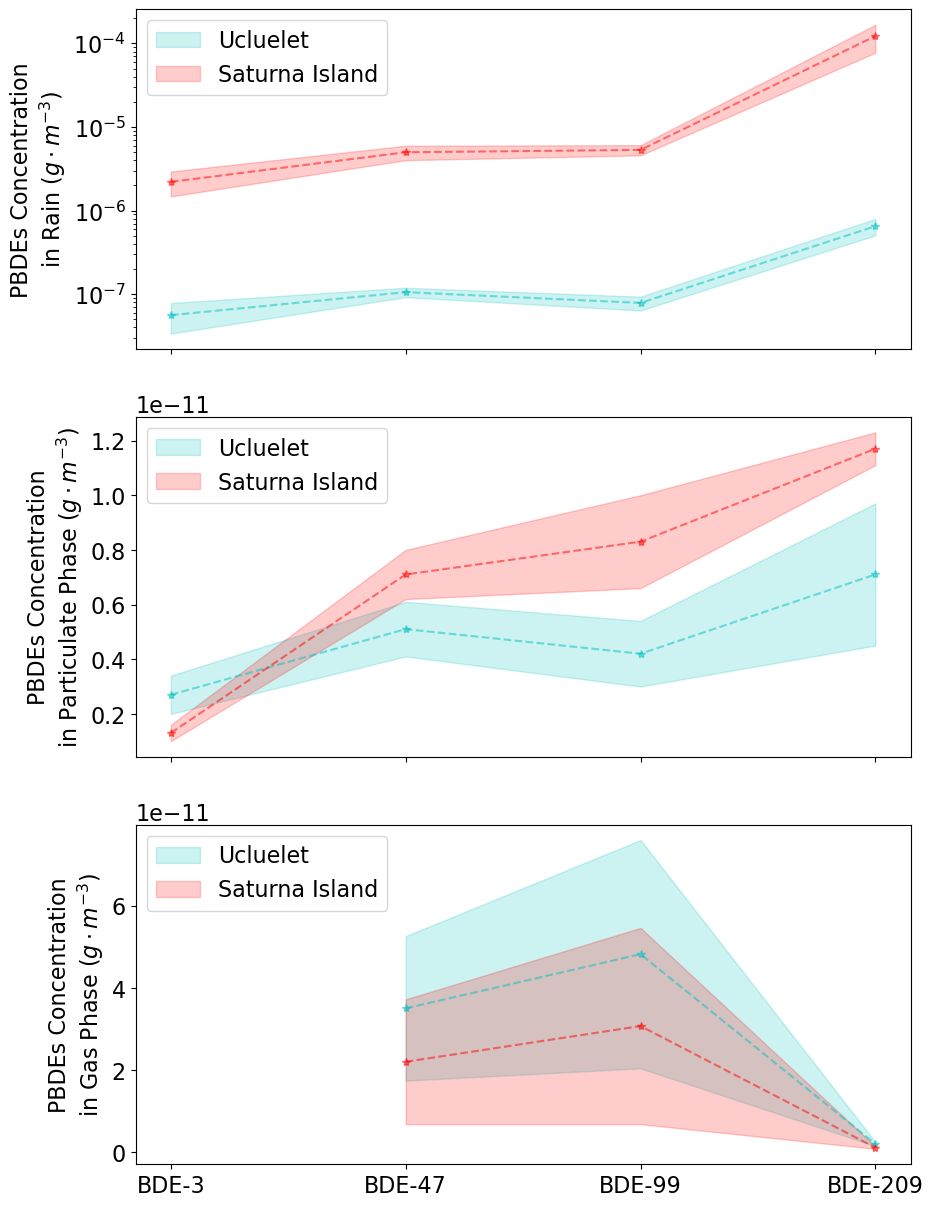

In [26]:
fig, ax = plt.subplots(3,1, figsize = (10, 15), sharex=True)
ax[0].fill_between(labels, ucluelet_rain_mean - ucluelet_rain_std, ucluelet_rain_mean + ucluelet_rain_std, color = location_color[0], alpha = .2, label = 'Ucluelet')
ax[0].plot(labels, ucluelet_rain_mean, location_color[0]+'--*', alpha = .5)
#
ax[0].fill_between(labels, saturna_rain_mean - saturna_rain_std, saturna_rain_mean + saturna_rain_std, color = location_color[1], alpha = .2, label = 'Saturna Island')
ax[0].plot(labels, saturna_rain_mean, location_color[1]+'--*', alpha = .5)
#
ax[0].set_ylabel('PBDEs Concentration' +'\n' + r'in Rain ($g \cdot m^{-3}$)')
ax[0].set_yscale('log')
#
ax[1].fill_between(labels, ucluelet_particulate_mean - ucluelet_particulate_std, ucluelet_particulate_mean + ucluelet_particulate_std, color = location_color[0], alpha = .2, label = 'Ucluelet')
ax[1].plot(labels, ucluelet_particulate_mean, location_color[0]+'--*', alpha = .5)
#
ax[1].fill_between(labels, saturna_particulate_mean - saturna_particulate_std, saturna_particulate_mean + saturna_particulate_std, color = location_color[1], alpha = .2, label = 'Saturna Island')
ax[1].plot(labels, saturna_particulate_mean, location_color[1]+'--*', alpha = .5)
ax[1].set_ylabel('PBDEs Concentration' +'\n' + r'in Particulate Phase ($g \cdot m^{-3}$)')
#
ax[2].fill_between(labels, ucluelet_gas_mean - ucluelet_gas_std, ucluelet_gas_mean + ucluelet_gas_std, color = location_color[0], alpha = .2, label = 'Ucluelet')
ax[2].plot(labels, ucluelet_gas_mean, location_color[0]+'--*', alpha = .5)
#
ax[2].fill_between(labels, saturna_gas_mean - saturna_gas_std, saturna_gas_mean + saturna_gas_std, color = location_color[1], alpha = .2, label = 'Saturna Island')
ax[2].plot(labels, saturna_gas_mean, location_color[1]+'--*', alpha = .5)
#
ax[2].set_ylabel('PBDEs Concentration' +'\n' + r'in Gas Phase ($g \cdot m^{-3}$)')
#
#
for axis in ax:
    axis.legend(loc='upper left')


# Seasonal Concentrations in Rain and Air

In [27]:
season_labels = ['Winter', 'Spring', 'Summer', 'Fall']

In [28]:
saturna_rain_mean = np.array([13016, 13923, 5334, 26762]) * 10e-9
ucluelet_rain_mean = np.array([172.1, 88, 58.4, 109.3]) * 10e-9
#
saturna_air_mean = np.array([7, 31.2, 4.9, 5.7]) * 10e-12
ucluelet_air_mean = np.array([14.9, 30.6, 4.3, 5.1]) * 10e-12
#
saturna_precipitation = np.array([199, 67, 159, 285])
ucluelet_precipitation = np.array([1037, 314, 463, 1456])

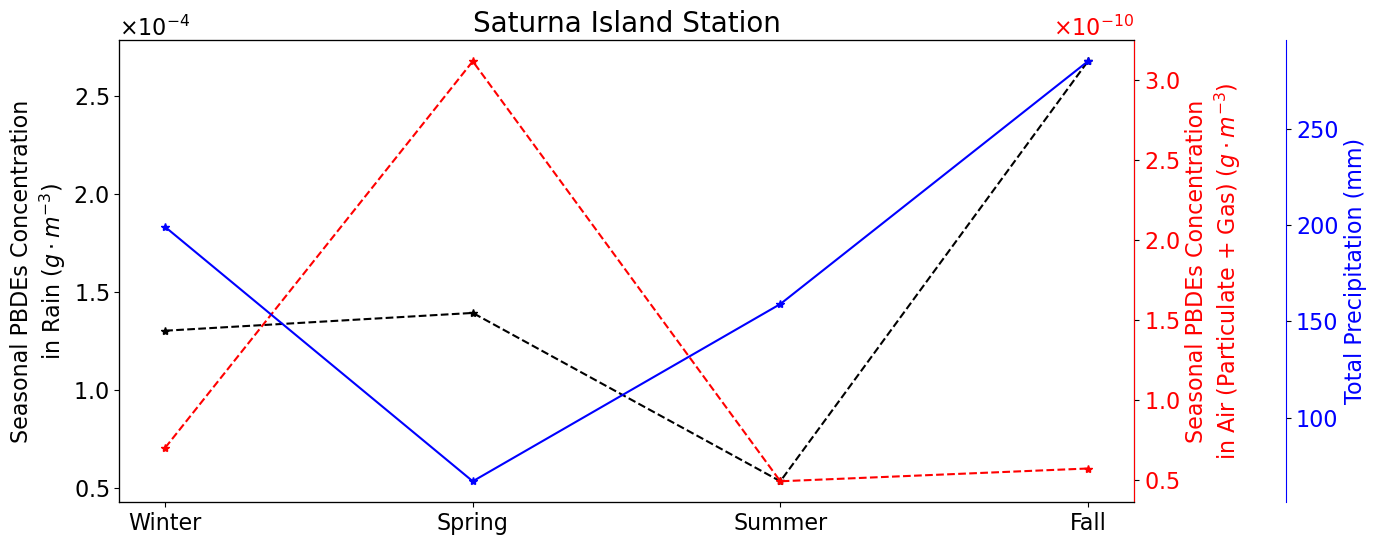

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

# Make room on the right side for the extra y-axis
fig.subplots_adjust(right=0.85)

# --- First Axis (Left): Black curve (saturna_rain_mean) ---
color_rain = 'black'
ax.plot(season_labels, saturna_rain_mean, '--*', color=color_rain)
ax.set_ylabel('Seasonal PBDEs Concentration' +'\n' + r'in Rain ($g \cdot m^{-3}$)', color=color_rain)
ax.tick_params(axis='y', labelcolor=color_rain)
ax.spines['left'].set_color(color_rain)
# --- Second Axis (Right, attached to plot edge): Red curve (saturna_air_mean) ---
ax2 = ax.twinx()
color_air = 'red'
ax2.plot(season_labels, saturna_air_mean, '--*', color=color_air)
ax2.set_ylabel('Seasonal PBDEs Concentration' +'\n' + r'in Air (Particulate + Gas) ($g \cdot m^{-3}$)', color=color_air)
ax2.tick_params(axis='y', labelcolor=color_air)
ax2.spines['right'].set_color(color_air)

# --- Third Axis (Right, offset): Blue curve (saturna_precipitation) ---
ax3 = ax.twinx()
color_precip = 'blue'

# Offset the third axis to the right by 15% (1.15) outside the axes
ax3.spines['right'].set_position(('axes', 1.15))

# Make sure the frame is on so the spine is visible
ax3.set_frame_on(True)
ax3.patch.set_visible(False)

ax3.plot(season_labels, saturna_precipitation, '-*', color=color_precip)
ax3.set_ylabel(r'Total Precipitation (mm)', color=color_precip)
ax3.tick_params(axis='y', labelcolor=color_precip)
ax3.spines['right'].set_color(color_precip)
#
for axis in [ax, ax2]:
    axis.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

plt.title('Saturna Island Station', fontsize = 20)
plt.show()

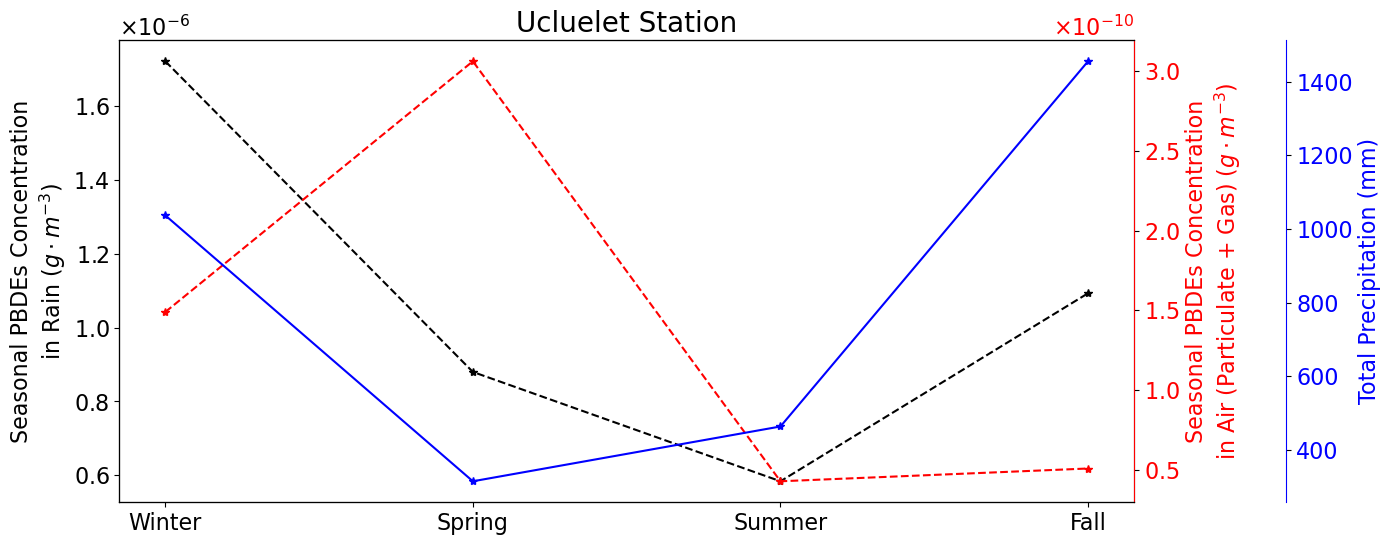

In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

# Make room on the right side for the extra y-axis
fig.subplots_adjust(right=0.85)

# --- First Axis (Left): Black curve (saturna_rain_mean) ---
color_rain = 'black'
ax.plot(season_labels, ucluelet_rain_mean, '--*', color=color_rain)
ax.set_ylabel('Seasonal PBDEs Concentration' +'\n' + r'in Rain ($g \cdot m^{-3}$)', color=color_rain)
ax.tick_params(axis='y', labelcolor=color_rain)
ax.spines['left'].set_color(color_rain)

# --- Second Axis (Right, attached to plot edge): Red curve (saturna_air_mean) ---
ax2 = ax.twinx()
color_air = 'red'
ax2.plot(season_labels, ucluelet_air_mean, '--*', color=color_air)
ax2.set_ylabel('Seasonal PBDEs Concentration' +'\n' + r'in Air (Particulate + Gas) ($g \cdot m^{-3}$)', color=color_air)
ax2.tick_params(axis='y', labelcolor=color_air)
ax2.spines['right'].set_color(color_air)

# --- Third Axis (Right, offset): Blue curve (saturna_precipitation) ---
ax3 = ax.twinx()
color_precip = 'blue'

# Offset the third axis to the right by 15% (1.15) outside the axes
ax3.spines['right'].set_position(('axes', 1.15))

# Make sure the frame is on so the spine is visible
ax3.set_frame_on(True)
ax3.patch.set_visible(False)

ax3.plot(season_labels, ucluelet_precipitation, '-*', color=color_precip)
ax3.set_ylabel(r'Total Precipitation (mm)', color=color_precip)
ax3.tick_params(axis='y', labelcolor=color_precip)
ax3.spines['right'].set_color(color_precip)
#
for axis in [ax, ax2]:
    axis.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
plt.title('Ucluelet Station', fontsize = 20)
plt.show()

# Comparison with Model? What is this compared to our estimates for the S1 region?

In [62]:
gg = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [ ]:
def surface_area_region(polygon, mesh_path='/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc', mask_path='/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc'):
    mesh = xr.open_dataset(mesh_path)
    mask_ds = xr.open_dataset(mask_path)
    cell_area = mesh['e1t'][0] * mesh['e2t'][0] 
    surface_mask = mask_ds['tmask'][0, 0]
    
    x = cell_area['x']  
    y = cell_area['y'] 
    
    xx, yy = np.meshgrid(x, y)
    
    polygon_mask_2d = np.array([
        [polygon.contains(Point(xx[j, i], yy[j, i])) for i in range(len(x))]
        for j in range(len(y))
    ])
    
    combined_mask_2d = polygon_mask_2d & (surface_mask.values == 1)
    mask_da = xr.DataArray(combined_mask_2d, dims=cell_area.dims, coords=cell_area.coords)
    surface_area_in_polygon = cell_area.where(mask_da).sum().item()
    
    return surface_area_in_polygon

In [52]:
from Regions_functions_V2 import polygon_S1, polygon_lon_lat_S1, polygon_coors_S1

In [79]:
saturna_yr_precipitation = saturna_precipitation.sum() * 1e-3
ucluelet_yr_precipitation = ucluelet_precipitation.sum() * 1e-3

In [ ]:
volume_S1 = 109.140915985 * 1e9 # m^3

In [ ]:
area_S1 = surface_area_region(polygon_S1) #m^2

In [88]:
gg_saturna_mean = []
gg_ucluelet_mean = []
gg_saturna_min = []
gg_ucluelet_min = []
gg_saturna_max = []
gg_ucluelet_max = []
for i in range(0, len(saturna_rain_mean)):
    caca_mean = (saturna_rain_mean[i]* saturna_yr_precipitation * area_S1) / volume_S1
    gg_saturna_mean.append(caca_mean)
    #
    caca1_mean = (ucluelet_rain_mean[i]* ucluelet_yr_precipitation * area_S1) / volume_S1
    gg_ucluelet_mean.append(caca1_mean) 
    #
    caca_min = ((saturna_rain_mean[i] - saturna_rain_std[i]) * saturna_yr_precipitation * area_S1) / volume_S1
    gg_saturna_min.append(caca_min)
    #
    caca1_min = ((ucluelet_rain_mean[i] - ucluelet_rain_std[i]) * ucluelet_yr_precipitation * area_S1) / volume_S1
    gg_ucluelet_min.append(caca1_min) 
    #
    caca_max = ((saturna_rain_mean[i] + saturna_rain_std[i]) * saturna_yr_precipitation * area_S1) / volume_S1
    gg_saturna_max.append(caca_max)
    #
    caca1_max = ((ucluelet_rain_mean[i] + ucluelet_rain_std[i]) * ucluelet_yr_precipitation * area_S1) / volume_S1
    gg_ucluelet_max.append(caca1_max)     

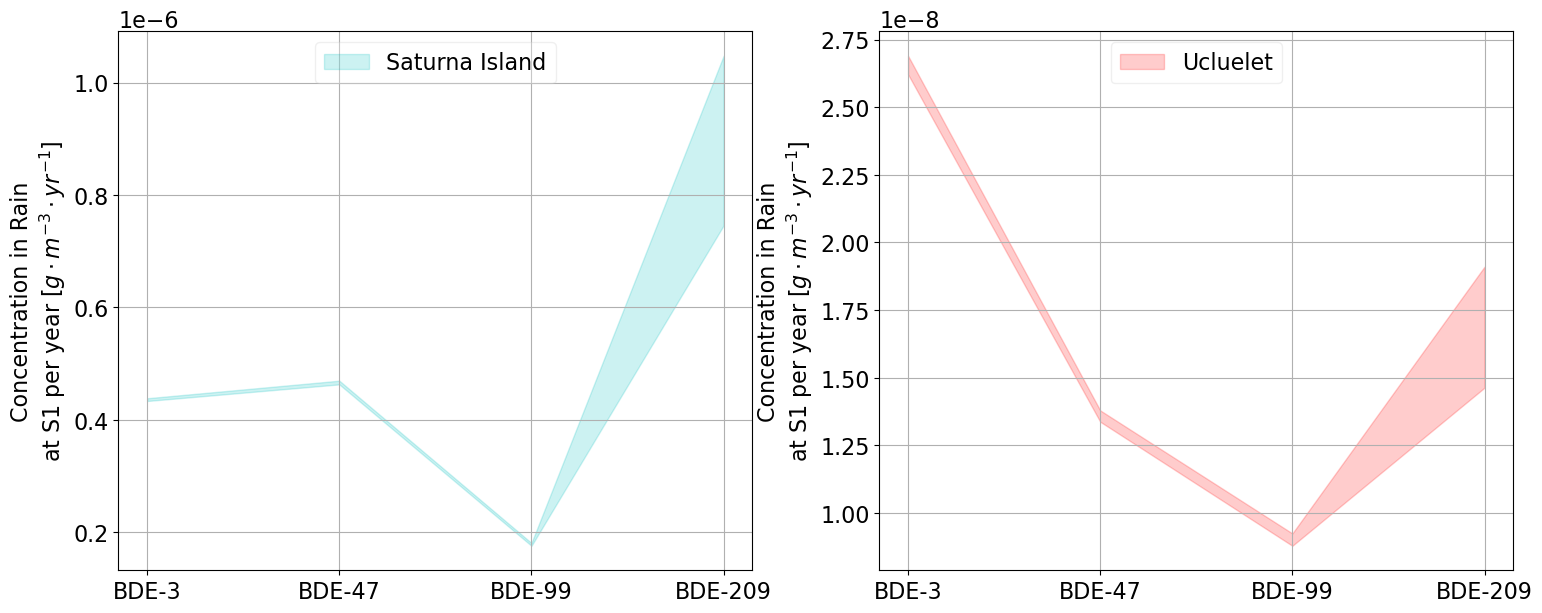

In [103]:
fig, ax = plt.subplots(1,2, figsize = (18,7))
ax[0].fill_between(labels, gg_saturna_min, gg_saturna_max, color = location_color[0], alpha = .2, label = 'Saturna Island')
ax[1].fill_between(labels, gg_ucluelet_min, gg_ucluelet_max, color = location_color[1], alpha = .2, label = 'Ucluelet')
#
for axis in ax:
    axis.set_ylabel(r'Concentration in Rain' + '\n' +'at S1 per year [$g \cdot m^{-3} \cdot yr^{-1}$]')
    axis.grid()
    axis.legend(loc = 'upper center', framealpha = .3)

In [76]:
saturna_rain_mean[0]

0.00013016000000000001